# Datarisk

### Desafio técnico de risco de crédito

### Objetivos:

1) Desenvolver um **modelo preditivo** que estime a **probabilidade de inadimplência** no processo de concessão de crédito;
2) Estruturar uma **política de crédito** fundamentada nas previsões geradas pelo modelo.

### Target: 

O Target escolhido foi o **ever30mob06**. Em geral, o volume encontrado é muito baixo, mas o mob06 já possui mais de 1% de bad rate e um tempo de 6 meses é apropriado para acompanhar o cliente.

ever30mob3:

    elegíveis = 101,372
    maus      = 333
    bad rate  = 0.3285%

ever30mob6:

    elegíveis = 83,744
    maus      = 854
    bad rate  = 1.0198%

ever30mob12:
    
    elegíveis = 37,712
    maus      = 774
    bad rate  = 2.0524%


### Métricas de desempenho:

Foram criados três modelos, um para cash loans e outro para Revolving loans e um híbrido que leva em conta o tipo de contrato como variável preditora.
Essa abordagem se faz necessária quando as populações de diferentes segmentos de crédito possuem comportamentos muito distintos entre si, o que dificulta a modelagem.

1) Modelo para Cash Loans

| Métrica  | Treino | Validação | Teste  |
|----------|--------|-----------|--------|
| AUC-ROC  | 0.85   | 0.54      | 0.62   |
| Gini     | 0.70   | 0.08      | 0.23   |
| KS       | 0.59   | 0.16      | 0.30   |
| PSI      | 1.13   | -         | -      |



3) Modelo para Revolving Loans


| Métrica  | Treino | Validação | Teste  |
|----------|--------|-----------|--------|
| AUC-ROC  | 0.90   | 0.49      | 0.58   |
| Gini     | 0.80   | -0.01     | 0.15   |
| KS       | 0.69   | 0.26      | 0.29   |
| PSI      | 1.82   | -         | -      |



4) Modelo Híbrido

| Métrica  | Treino | Validação | Teste  |
|----------|--------|-----------|--------|
| AUC-ROC  | 0.79   | 0.53      | 0.60   |
| Gini     | 0.58   | 0.08      | 0.21   |
| KS       | 0.42   | 0.11      | 0.25   |
| PSI      | 1.92   | -         | -      |
    

In [1]:
from platform import python_version
print("Versão Python usada neste notebook:", python_version())

Versão Python usada neste notebook: 3.12.7


In [2]:
# Instalação dos pacotes
# !pip install -q lightgbm

In [15]:
# Carregamento dos pacotes

import re

import pandas as pd
import numpy as np

from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb

from IPython.display import display, Markdown
from warnings import filterwarnings
filterwarnings("ignore")
filterwarnings("ignore", category=UserWarning, module="lightgbm")

import watermark

In [4]:
%reload_ext watermark
%watermark --iversions -v

Python implementation: CPython
Python version       : 3.12.7
IPython version      : 8.27.0

IPython   : 8.27.0
ipywidgets: 7.8.1
json      : 2.0.9
lightgbm  : 4.6.0
matplotlib: 3.9.2
numpy     : 1.26.4
pandas    : 2.2.2
platform  : 1.0.8
seaborn   : 0.13.2
sklearn   : 1.5.1
sys       : 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
watermark : 2.5.1
xarray    : 2023.6.0



In [5]:
# Carrega os dados e aplica transformações nos tipos de variáveis
path_arquivos = "data/"

df_dicionario = pd.read_csv(f"{path_arquivos}dicionario_dados.csv", delimiter=";")
df_cadastro = pd.read_parquet(f"{path_arquivos}base_cadastral.parquet")
df_contrato = pd.read_parquet(f"{path_arquivos}historico_emprestimos.parquet")
df_parcelas = pd.read_parquet(f"{path_arquivos}historico_parcelas.parquet")
df_submissao = pd.read_parquet(f"{path_arquivos}base_submissao.parquet")


def resumo_df(nome, df):
    print(f"{nome}:\t {df.shape[0]}")

print("Número de linhas de cada dataset:")
resumo_df("Dicionário", df_dicionario)
resumo_df("Cadastro", df_cadastro)
resumo_df("Contrato", df_contrato)
resumo_df("Parcelas", df_parcelas)
resumo_df("Submissão", df_submissao)


# Cadastro
df_cadastro["id_cliente"] = df_cadastro["id_cliente"].astype("object")
df_cadastro["data_nascimento"] = pd.to_datetime(df_cadastro["data_nascimento"], errors="coerce")
df_cadastro["idade"] = ((pd.Timestamp.today() - df_cadastro["data_nascimento"]).dt.days // 365)

# Contrato
df_contrato["id_cliente"] = df_contrato["id_cliente"].astype("object")
df_contrato["id_contrato"] = df_contrato["id_contrato"].astype("object")

colunas_datas_contrato = [
    "data_decisao",
    "data_encerramento",
    "data_liberacao",
    "data_primeiro_vencimento",
    "data_ultimo_vencimento",
    "data_ultimo_vencimento_original"
]
for col in colunas_datas_contrato:
    if col in df_contrato.columns:
        df_contrato[col] = pd.to_datetime(df_contrato[col], errors="coerce")

# Parcelas
df_parcelas["id_cliente"] = df_parcelas["id_cliente"].astype("object")
df_parcelas["id_contrato"] = df_parcelas["id_contrato"].astype("object")
df_parcelas["data_prevista_pagamento"] = pd.to_datetime(df_parcelas["data_prevista_pagamento"], errors="coerce")
df_parcelas["data_real_pagamento"] = pd.to_datetime(df_parcelas["data_real_pagamento"], errors="coerce")
df_parcelas = df_parcelas.groupby(["id_cliente", "id_contrato", "numero_parcela"]).agg({
    "data_prevista_pagamento": "first",
    "data_real_pagamento"    : "max",
    "valor_previsto_parcela" : "first",
    "valor_pago_parcela"     : "sum"
}).reset_index()

# Data de corte
data_corte = max(
    df_parcelas["data_prevista_pagamento"].max(),
    df_parcelas["data_real_pagamento"].max()
)

print("\nData de corte:", data_corte)

# Tratamento de atraso (considera não pagos como atraso até data_corte)
df_parcelas["dias_atraso"] = ((df_parcelas["data_real_pagamento"].fillna(data_corte) - df_parcelas["data_prevista_pagamento"]).dt.days)

print("\nDias de atraso:")
print("30 dias ou mais:", (df_parcelas["dias_atraso"] >= 30).sum())
print("Valores ausentes:", df_parcelas["dias_atraso"].isna().sum())

Número de linhas de cada dataset:
Dicionário:	 69
Cadastro:	 40000
Contrato:	 186890
Parcelas:	 1390978
Submissão:	 40000

Data de corte: 2025-02-22 00:00:00

Dias de atraso:
30 dias ou mais: 4605
Valores ausentes: 0


# Definição do TARGET

Antes da construção do modelo, é fundamental estabelecer o critério de **Default** (inadimplência). Existem diversas abordagens consolidadas no mercado para essa definição, tais como **FPD** (First Payment Default), **ever30mob03**, **ever30mob06** e **ever30mob12**.

Iniciaremos com a análise do conjunto de dados para, em seguida, determinar a estratégia mais adequada para os objetivos deste desafio.

Dataset TARGET:


,id_cliente,id_contrato,data_decisao,elegivel_mob3,ever30mob3,elegivel_mob6,ever30mob6,elegivel_mob12,ever30mob12
0,108129,2802425,2024-08-29,True,0.0,False,NaN,False,NaN
1,258628,2330894,2022-10-11,True,0.0,True,0.0,True,0.0
2,267782,1182516,2023-04-08,True,0.0,True,0.0,True,0.0
3,275707,1543131,2024-02-08,True,0.0,True,0.0,False,NaN
4,299391,2261993,2024-09-06,False,NaN,False,NaN,False,NaN


ever30mob3:
  elegíveis = 101,372
  maus      = 333
  bad rate  = 0.3285%

ever30mob6:
  elegíveis = 83,744
  maus      = 854
  bad rate  = 1.0198%

ever30mob12:
  elegíveis = 37,712
  maus      = 774
  bad rate  = 2.0524%



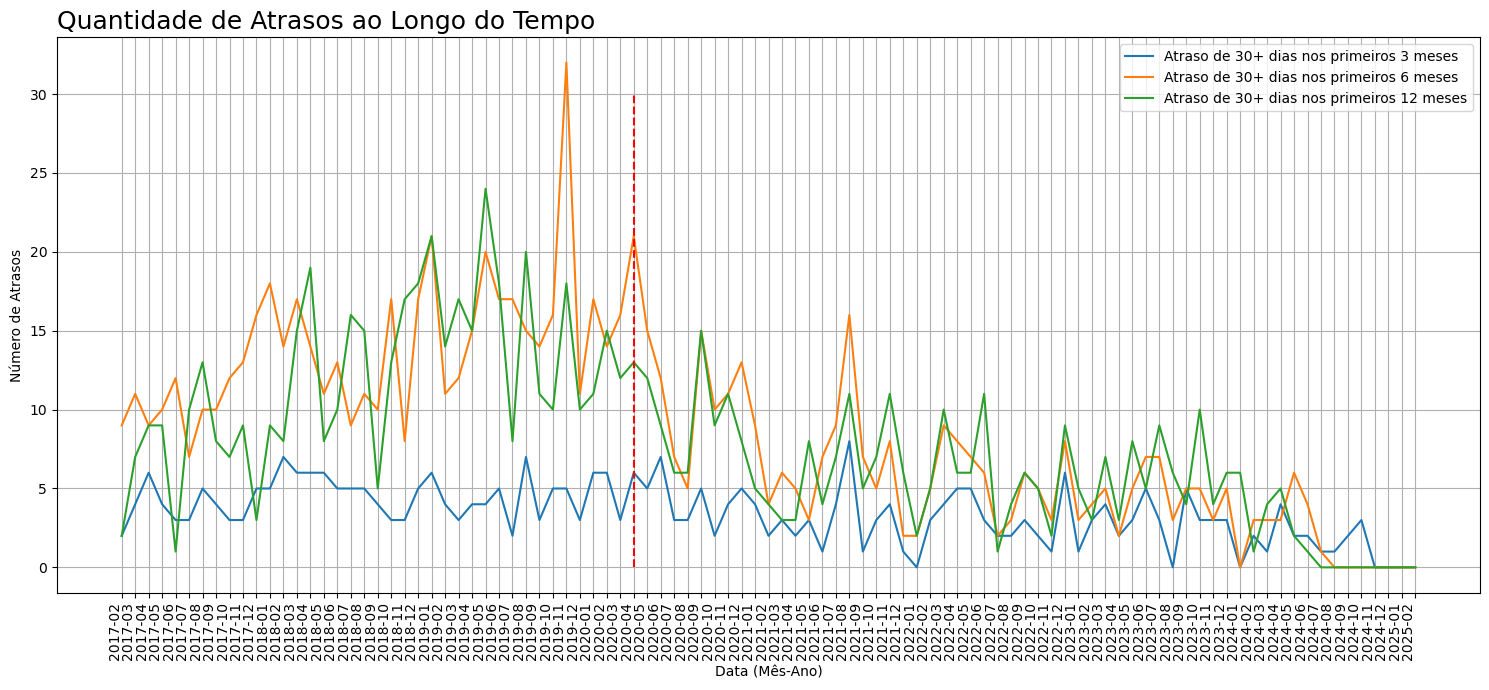

In [20]:
# Função de target
def criar_target_ever30(contrato, parcelas, mob, data_corte):
    """
    Cria o target ever30mobX no nível do contrato
    
    Regras:
    - Considera parcelas até o número da parcela = mob
    - Um contrato é dado com bad se em alguma dessas parcelas tiver um dias_atraso >= 30
    - Um contrato é elegível se a parcela do MOB X venceu pelo menos 30 dias antes da data final de corte
    
    Input:
        dataframe contrato
        dataframe target
        mob

    Output:
        serie com o indicador se é mobX ou não
    """
    
    if "numero_parcela" not in parcelas.columns:
        raise ValueError("Coluna 'numero_parcela' não encontrada no DataFrame")

    base_mob = parcelas[parcelas["numero_parcela"] <= mob].copy()

    max_dias_atraso = (
        base_mob.groupby("id_contrato")["dias_atraso"]
        .max()
        .reset_index()
        .rename(columns={"dias_atraso": f"max_dias_atraso_mob{mob}"})
    )

    parcela_alvo = (
        parcelas[parcelas["numero_parcela"] == mob][
            ["id_contrato", "data_prevista_pagamento"]
        ]
        .drop_duplicates("id_contrato")
        .rename(columns={
            "data_prevista_pagamento": f"data_vencimento_mob{mob}"
        })
    )

    base_target = (
        contrato[["id_contrato"]]
        .drop_duplicates()
        .merge(max_dias_atraso, on="id_contrato", how="left")
        .merge(parcela_alvo, on="id_contrato", how="left")
    )

    base_target[f"elegivel_mob{mob}"] = (
        base_target[f"data_vencimento_mob{mob}"].notna() &
        (base_target[f"data_vencimento_mob{mob}"] <= data_corte - pd.Timedelta(days=30))
    )

    base_target[f"ever30mob{mob}"] = np.where(
        base_target[f"elegivel_mob{mob}"],
        (base_target[f"max_dias_atraso_mob{mob}"] >= 30).astype(int),
        np.nan
    )
    return base_target

# Targets
ever30mob03 = criar_target_ever30(df_contrato, df_parcelas, mob=3, data_corte=data_corte)
ever30mob06 = criar_target_ever30(df_contrato, df_parcelas, mob=6, data_corte=data_corte)
ever30mob12 = criar_target_ever30(df_contrato, df_parcelas, mob=12, data_corte=data_corte)

# Dataset final
df_target = (
    df_contrato[['id_cliente', 'id_contrato', 'data_decisao']]
    .drop_duplicates()
    .merge(ever30mob03[['id_contrato', 'elegivel_mob3', 'ever30mob3']], on='id_contrato', how='left')
    .merge(ever30mob06[['id_contrato', 'elegivel_mob6', 'ever30mob6']], on='id_contrato', how='left')
    .merge(ever30mob12[['id_contrato', 'elegivel_mob12', 'ever30mob12']], on='id_contrato', how='left')
)

print("Dataset TARGET:")
display(df_target.head())

# Métricas

for mob in [3, 6, 12]:
    elegiveis = df_target[df_target[f'elegivel_mob{mob}'] == True]
    taxa      = elegiveis[f'ever30mob{mob}'].mean()
    qtd_bad   = elegiveis[f'ever30mob{mob}'].sum()
    qtd_total = elegiveis.shape[0]
    
    
    print(f'ever30mob{mob}:')
    print(f'  elegíveis = {qtd_total:,}')
    print(f'  maus      = {int(qtd_bad):,}')
    print(f'  bad rate  = {taxa:.4%}')
    print()





# Ever30mobX window over the time
df_target['data_decisao_mes_ano'] = df_target['data_decisao'].dt.to_period('M')

defaults_over_time = df_target.groupby('data_decisao_mes_ano')[['ever30mob3', 'ever30mob6', 'ever30mob12']].sum().reset_index()
defaults_over_time['data_decisao_mes_ano'] = defaults_over_time['data_decisao_mes_ano'].astype(str)

plt.figure(figsize=(15, 7))

sns.lineplot(x='data_decisao_mes_ano', y='ever30mob3', data=defaults_over_time, label='Atraso de 30+ dias nos primeiros 3 meses')
sns.lineplot(x='data_decisao_mes_ano', y='ever30mob6', data=defaults_over_time, label='Atraso de 30+ dias nos primeiros 6 meses')
sns.lineplot(x='data_decisao_mes_ano', y='ever30mob12', data=defaults_over_time, label='Atraso de 30+ dias nos primeiros 12 meses')

plt.vlines(x="2020-04", ymin=0, ymax=30, colors='r', linestyles='--')

plt.title('Quantidade de Atrasos ao Longo do Tempo', loc='left', size=18)
plt.xlabel('Data (Mês-Ano)')
plt.ylabel('Número de Atrasos')
plt.xticks(rotation=90, ha='right')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Dataset TARGET:


,id_cliente,id_contrato,data_decisao,elegivel_mob3,ever30mob3,elegivel_mob6,ever30mob6,elegivel_mob12,ever30mob12
0,108129,2802425,2024-08-29,True,0.0,False,NaN,False,NaN
1,258628,2330894,2022-10-11,True,0.0,True,0.0,True,0.0
2,267782,1182516,2023-04-08,True,0.0,True,0.0,True,0.0
3,275707,1543131,2024-02-08,True,0.0,True,0.0,False,NaN
4,299391,2261993,2024-09-06,False,NaN,False,NaN,False,NaN


ever30mob3:
  elegíveis = 101,372
  maus      = 333
  bad rate  = 0.3285%

ever30mob6:
  elegíveis = 83,744
  maus      = 854
  bad rate  = 1.0198%

ever30mob12:
  elegíveis = 37,712
  maus      = 774
  bad rate  = 2.0524%



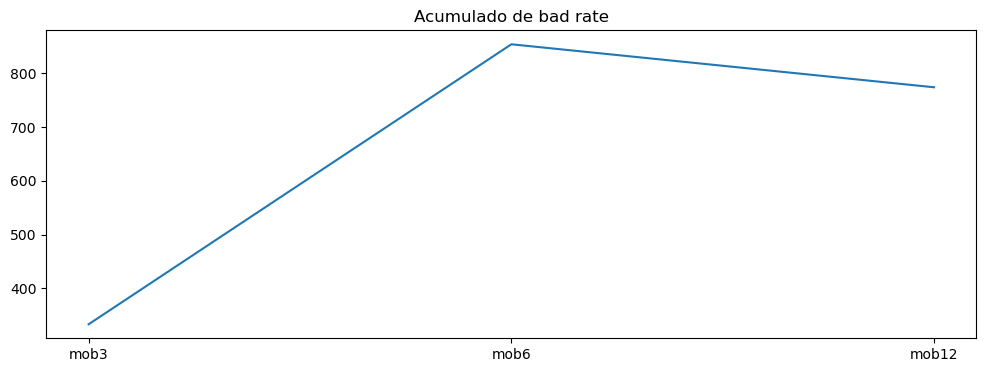

In [29]:
def criar_target_ever30(contrato, parcelas, mob, data_corte):
    """
    Cria o target ever30mobX no nível do contrato
    
    Regras:
    - Considera parcelas até o número da parcela = mob
    - Bad = max(dias_atraso) >= 30
    - Elegível = parcela MOB venceu há pelo menos 30 dias
    
    Retorna:
        id_contrato | elegivel_mobX | ever30mobX
    """

    # Validação
    if "numero_parcela" not in parcelas.columns:
        raise ValueError("Coluna 'numero_parcela' não encontrada")

    # -------------------------
    # 1. Base até o MOB
    # -------------------------
    base_mob = parcelas[parcelas["numero_parcela"] <= mob].copy()

    # Garante que dias_atraso não quebra o max
    base_mob["dias_atraso"] = base_mob["dias_atraso"].fillna(0)

    max_dias_atraso = (
        base_mob.groupby("id_contrato", as_index=False)["dias_atraso"]
        .max()
        .rename(columns={"dias_atraso": f"max_dias_atraso_mob{mob}"})
    )

    # -------------------------
    # 2. Data da parcela MOB
    # -------------------------
    parcela_alvo = (
        parcelas.loc[parcelas["numero_parcela"] == mob,
                     ["id_contrato", "data_prevista_pagamento"]]
        .drop_duplicates("id_contrato")
        .rename(columns={
            "data_prevista_pagamento": f"data_vencimento_mob{mob}"
        })
    )

    # -------------------------
    # 3. Merge base
    # -------------------------
    base_target = (
        contrato[["id_contrato"]]
        .drop_duplicates()
        .merge(max_dias_atraso, on="id_contrato", how="left")
        .merge(parcela_alvo, on="id_contrato", how="left")
    )

    # -------------------------
    # 4. Elegibilidade
    # -------------------------
    base_target[f"elegivel_mob{mob}"] = (
        base_target[f"data_vencimento_mob{mob}"].notna() &
        (base_target[f"data_vencimento_mob{mob}"] <= data_corte - pd.Timedelta(days=30))
    )

    # -------------------------
    # 5. Evento (somente para elegíveis)
    # -------------------------
    base_target[f"ever30mob{mob}"] = np.where(
        base_target[f"elegivel_mob{mob}"],
        (base_target[f"max_dias_atraso_mob{mob}"].fillna(0) >= 30).astype(int),
        np.nan
    )

    return base_target[
        ["id_contrato", f"elegivel_mob{mob}", f"ever30mob{mob}"]
    ]

# Targets
ever30mob03 = criar_target_ever30(df_contrato, df_parcelas, mob=3, data_corte=data_corte)
ever30mob06 = criar_target_ever30(df_contrato, df_parcelas, mob=6, data_corte=data_corte)
ever30mob12 = criar_target_ever30(df_contrato, df_parcelas, mob=12, data_corte=data_corte)

# Dataset final
df_target = (
    df_contrato[['id_cliente', 'id_contrato', 'data_decisao']]
    .drop_duplicates()
    .merge(ever30mob03[['id_contrato', 'elegivel_mob3', 'ever30mob3']], on='id_contrato', how='left')
    .merge(ever30mob06[['id_contrato', 'elegivel_mob6', 'ever30mob6']], on='id_contrato', how='left')
    .merge(ever30mob12[['id_contrato', 'elegivel_mob12', 'ever30mob12']], on='id_contrato', how='left')
)

print("Dataset TARGET:")
display(df_target.head())

# Métricas
cumulative_bad_rate = []
for mob in [3, 6, 12]:
    elegiveis = df_target[df_target[f'elegivel_mob{mob}'] == True]

    taxa = elegiveis[f'ever30mob{mob}'].mean()
    qtd_bad = elegiveis[f'ever30mob{mob}'].sum()
    qtd_total = elegiveis.shape[0]
    cumulative_bad_rate.append(qtd_bad)
    
    print(f'ever30mob{mob}:')
    print(f'  elegíveis = {qtd_total:,}')
    print(f'  maus      = {int(qtd_bad):,}')
    print(f'  bad rate  = {taxa:.4%}')
    print()

plt.figure(figsize=(12,4))
plt.plot(["mob3", "mob6", "mob12"],cumulative_bad_rate )
plt.title("Acumulado de bad rate")
plt.show()

Pode ser observado dois pontos de atenção nesta análise:

1) Baixo volume de maus pagadores na base, que apesar de desejável no cenário de crédito, é um desafio para a modelagem do comportamento e;
2) Mudança no número de atrasos ao longo do tempo com efeito mais expressivo nas categorias **ever30mob06** e **ever30mob12** a partir de Maio de 2020.

A escolha do TARGET será "ever30mob06" devido ao volume.

In [16]:
TARGET = "ever30mob6"

match = re.search(r"mob(\d+)", TARGET.lower())

if not match:
    raise ValueError(f"Não foi possível extrair MOB do TARGET: {TARGET}")

mob = match.group(1)
col_elegivel = f"elegivel_mob{mob}"

print(f"Target selecionado: {TARGET}")
print(f"Coluna de elegibilidade usada: {col_elegivel}")

Target selecionado: ever30mob12
Coluna de elegibilidade usada: elegivel_mob12


# Modelagem

In [12]:
# =========================
# Funções auxiliares
# =========================
def calcular_gini(y_true, y_prob):
    return 2 * roc_auc_score(y_true, y_prob) - 1


def calcular_ks(y_true, y_prob):
    df = pd.DataFrame({"y": y_true, "prob": y_prob}).sort_values("prob")
    df["cum_good"] = (df["y"] == 0).cumsum() / (df["y"] == 0).sum()
    df["cum_bad"]  = (df["y"] == 1).cumsum() / (df["y"] == 1).sum()
    return np.max(np.abs(df["cum_bad"] - df["cum_good"]))


def calcular_psi(expected, actual, buckets=10):
    breakpoints   = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    expected_bins = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_bins   = np.histogram(actual,   bins=breakpoints)[0] / len(actual)
    return np.sum((actual_bins - expected_bins) * np.log((actual_bins + 1e-6) / (expected_bins + 1e-6)))


def treinar_modelo(df_subset, features, target=TARGET):
    train = df_subset[df_subset["ano_decisao"] <= 2022]
    val   = df_subset[df_subset["ano_decisao"] == 2023]
    test  = df_subset[df_subset["ano_decisao"] >= 2024]

    X_train, y_train = train[features], train[target]
    X_val,   y_val   = val[features],   val[target]
    X_test,  y_test  = test[features],  test[target]

    # Filtra apenas as CAT_COLS presentes nas features do modelo
    cat_features = [c for c in CAT_COLS if c in features]

    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1,
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        categorical_feature=cat_features or "auto",
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
    )

    print(f"  → Treino: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
    return model, X_train, y_train, X_val, y_val, X_test, y_test


def avaliar_modelo(nome_modelo, model, splits):
    X_train, y_train, X_val, y_val, X_test, y_test = splits
    resultados = []

    for nome_split, X, y in [
        ("Train",      X_train, y_train),
        ("Val",        X_val,   y_val),
        ("Test (OOT)", X_test,  y_test),
    ]:
        prob = model.predict_proba(X)[:, 1]
        auc  = roc_auc_score(y, prob)
        resultados.append({
            "Modelo": nome_modelo,
            "Split":  nome_split,
            "AUC":    round(auc,                   4),
            "Gini":   round(2 * auc - 1,           4),
            "KS":     round(calcular_ks(y, prob),  4),
        })

    prob_train = model.predict_proba(X_train)[:, 1]
    prob_test  = model.predict_proba(X_test)[:, 1]
    resultados[-1]["PSI (Train→Test)"] = round(calcular_psi(prob_train, prob_test), 4)

    return pd.DataFrame(resultados)


def plot_feature_importances(modelos, top_n=10):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.flatten()

    for i, m in enumerate(modelos):
        feat_imp = (
            pd.DataFrame({"feature": m["features"], "importance": m["model"].feature_importances_})
            .sort_values("importance", ascending=False)
            .head(top_n)
        )
        ax = axes[i]
        bars = ax.barh(feat_imp["feature"][::-1], feat_imp["importance"][::-1], color="#4C72B0")
        ax.bar_label(bars, fmt="%.0f", padding=4, fontsize=9)
        ax.set_xlabel("Importância (split gain)")
        ax.set_title(f"{m['nome']} — Top {top_n} Features", fontsize=12, fontweight="bold")
        ax.spines[["top", "right"]].set_visible(False)

    axes[-1].set_visible(False)
    plt.suptitle("Importância das Features por Modelo", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


def criar_buckets(df: pd.DataFrame, col: str, bins: np.ndarray) -> pd.DataFrame:
    df = df.copy()
    n  = len(bins) - 1
    df[f"{col}_bucket"] = pd.cut(
        df[col],
        bins=bins,
        include_lowest=True,
        labels=[f"B{i+1}" for i in range(n)],
    )
    return df


def resumo_buckets(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """Retorna contagem e estatísticas de probabilidade por bucket."""
    return (
        df.groupby(f"{col}_bucket", observed=False)
        .agg(
            contagem=(col, "size"),
            prob_min =(col, "min"),
            prob_med =(col, "mean"),
            prob_max =(col, "max"),
        )
        .reset_index()
        .rename(columns={f"{col}_bucket": "bucket"})
    )

def comparar_buckets(df: pd.DataFrame, n_buckets: int = 3) -> tuple[pd.DataFrame, pd.DataFrame]:
    bins = np.linspace(0, 1, n_buckets + 1)

    df = criar_buckets(df, "prob_segmentado", bins)
    df = criar_buckets(df, "prob_hibrido",    bins)

    seg = resumo_buckets(df, "prob_segmentado").add_prefix("seg_").rename(columns={"seg_bucket": "bucket"})
    hib = resumo_buckets(df, "prob_hibrido").add_prefix("hib_").rename(columns={"hib_bucket": "bucket"})

    comparacao = seg.merge(hib, on="bucket")
    return df, comparacao


def plot_distribuicao_probabilidades(df_sub: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, col, titulo in zip(
        axes,
        ["prob_segmentado", "prob_hibrido"],
        ["Modelo Segmentado", "Modelo Híbrido"],
    ):
        sns.histplot(df_sub[col], ax=ax, bins=30, kde=True)
        ax.set_title(titulo, fontsize=13, fontweight="bold")
        ax.set_xlabel("Probabilidade de Default")
        ax.set_ylabel("Frequência")

    plt.suptitle("Distribuição das Probabilidades Preditas", fontsize=18, fontweight="bold")
    plt.tight_layout()
    plt.show()


In [17]:
# =========================
# Base de modelagem
# =========================

CAT_COLS  = [
    "estado_civil", 
    "sexo", 
    "nivel_educacao", 
    "tipo_moradia", 
    "tipo_contrato"
]


df_modelo = (
    df_target
    .drop(columns=["data_decisao"])
    .merge(df_contrato, on=["id_cliente", "id_contrato"], how="left")
    .merge(df_cadastro, on="id_cliente", how="left")
)



df_modelo = (
    df_modelo
    [df_modelo[col_elegivel] == True]
    [df_modelo[TARGET].notna()]
    .copy()
)

print("Escolha do target:", TARGET)

# =========================
# Features
# =========================
variaveis_cadastro = ["renda_anual", "estado_civil", "sexo", "nivel_educacao", "tipo_moradia"]
variaveis_cadastro = [col for col in variaveis_cadastro if col in df_modelo.columns]

features = ["idade"] + variaveis_cadastro

# Datas
if "data_decisao" in df_modelo.columns:
    df_modelo["ano_decisao"] = df_modelo["data_decisao"].dt.year
    df_modelo["mes_decisao"] = df_modelo["data_decisao"].dt.month
    features += ["ano_decisao", "mes_decisao"]

# Tipos
for col in CAT_COLS:
    if col in df_modelo.columns:
        df_modelo[col] = df_modelo[col].astype("category")

df_modelo = df_modelo.dropna(subset=features)

features_base    = features.copy()
features_hibrido = features_base + ["tipo_contrato"]


# =========================
# Treinamento
# =========================
modelos_config = [
    {
        "nome":     "Cash Loans",
        "filtro":   df_modelo["tipo_contrato"] == "Cash loans",
        "features": features_base,
    },
    {
        "nome":     "Revolving Loans",
        "filtro":   df_modelo["tipo_contrato"] == "Revolving loans",
        "features": features_base,
    },
    {
        "nome":     "Híbrido",
        "filtro":   slice(None),   # sem filtro — usa o df completo
        "features": features_hibrido,
    },
]

modelos_treinados = {}

for cfg in modelos_config:
    print("=" * 50)
    print(f"Modelo — {cfg['nome']}")
    subset = df_modelo[cfg["filtro"]].copy() if isinstance(cfg["filtro"], pd.Series) else df_modelo.copy()
    model, *splits = treinar_modelo(subset, cfg["features"])
    modelos_treinados[cfg["nome"]] = {"model": model, "splits": splits, "features": cfg["features"]}

model_cash = modelos_treinados["Cash Loans"]["model"]
model_rev  = modelos_treinados["Revolving Loans"]["model"]
model_hyb  = modelos_treinados["Híbrido"]["model"]

# =========================
# Avaliação comparativa
# =========================
df_eval = pd.concat([
    avaliar_modelo(nome, v["model"], v["splits"])
    for nome, v in modelos_treinados.items()
], ignore_index=True)

print("\n\n"+"="*50+"\n\n")

display(
    df_eval.fillna("-").style
    .set_caption("📊 Comparativo dos 3 Modelos")
    .highlight_max(subset=["AUC", "Gini", "KS"], color="#d4edda")
    .highlight_min(subset=["AUC", "Gini", "KS"], color="#f8d7da")
    .set_table_styles([{"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}])
)

print("\n\n")

plot_feature_importances([
    {"nome": nome, "model": v["model"], "features": v["features"]}
    for nome, v in modelos_treinados.items()
])

KeyError: 'elegivel_mob12'

In [9]:
# =========================
# Scoring
# =========================
df_sub = df_submissao.merge(df_cadastro, on="id_cliente", how="left")
df_sub["data_decisao"] = pd.Timestamp.today().normalize()
df_sub["ano_decisao"]  = df_sub["data_decisao"].dt.year
df_sub["mes_decisao"]  = df_sub["data_decisao"].dt.month

for col in CAT_COLS:
    if col in df_sub.columns:
        df_sub[col] = df_sub[col].astype("category")

# Modelo segmentado
mask_cash = df_sub["tipo_contrato"] == "Cash loans"
mask_rev  = df_sub["tipo_contrato"] == "Revolving loans"

df_sub["prob_segmentado"] = float("nan")
df_sub.loc[mask_cash, "prob_segmentado"] = model_cash.predict_proba(df_sub.loc[mask_cash, features_base])[:, 1]
df_sub.loc[mask_rev,  "prob_segmentado"] = model_rev.predict_proba( df_sub.loc[mask_rev,  features_base])[:, 1]

nulos_seg = df_sub["prob_segmentado"].isna().sum()
if nulos_seg > 0:
    print(f"⚠️  {nulos_seg} linhas sem predição no segmentado (tipo_contrato inesperado)")

# Modelo híbrido
df_sub["prob_hibrido"] = model_hyb.predict_proba(df_sub[features_hibrido])[:, 1]

,id_cliente,prob_segmentado,prob_hibrido,prob_segmentado_bucket,prob_hibrido_bucket
22958,336571,0.010628,0.005019,B1,B1
24190,349204,0.008995,0.005142,B1,B1
10111,205437,0.009553,0.004681,B1,B1
26234,370620,0.009164,0.005180,B1,B1
6720,169724,0.008341,0.006952,B1,B1
1107,111939,0.009417,0.006698,B1,B1
6308,165330,0.009270,0.004714,B1,B1
4613,147778,0.010255,0.012235,B1,B1
25198,359786,0.009308,0.007688,B1,B1
1442,115555,0.008849,0.002587,B1,B1


  bucket  seg_contagem  seg_prob_min  seg_prob_med  seg_prob_max  \
0     B1         40000      0.008021      0.009467      0.031917   
1     B2             0           NaN           NaN           NaN   
2     B3             0           NaN           NaN           NaN   

   hib_contagem  hib_prob_min  hib_prob_med  hib_prob_max  
0         40000      0.002048      0.006802       0.25581  
1             0           NaN           NaN           NaN  
2             0           NaN           NaN           NaN  


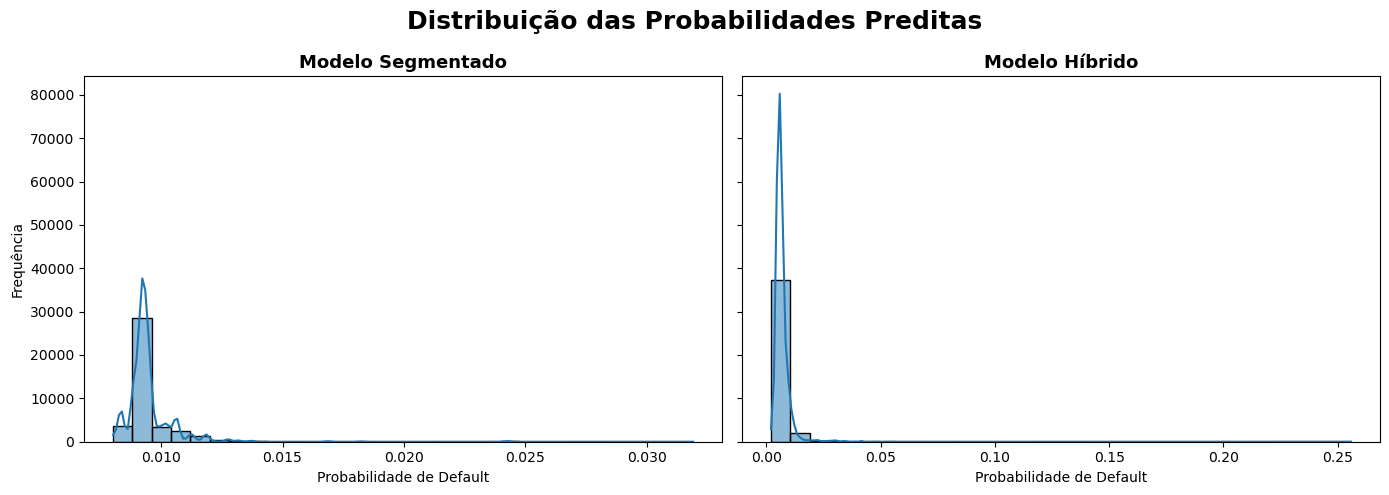

In [10]:
df_resultado, tabela = comparar_buckets(
    df_sub[["id_cliente", "prob_segmentado", "prob_hibrido"]],
    n_buckets=3,
)

display(df_resultado.sample(10))
print(tabela)

plot_distribuicao_probabilidades(df_sub)

In [11]:
# =========================
# Exportação
# =========================
df_sub = df_sub.rename(columns={"prob_segmentado":"probabilidade_inadimplencia"})
df_sub[["id_cliente", "probabilidade_inadimplencia"]].to_csv(f"submissao_case.csv", index=False)

print("✅ CSV gerado com sucesso:")
print(f"   → submissao_case.csv          ({mask_cash.sum()} cash + {mask_rev.sum()} revolving)")

✅ CSV gerado com sucesso:
   → submissao_case.csv          (36599 cash + 3401 revolving)
